# K-Means Cluster Analysis (Ian_ML Architecture)
## Identifying Ahlqvist T2DM Subtypes using Two-Tiered Clustering

**Methodology:** Following the 2018 *Lancet* paper by Ahlqvist et al., implemented with `Ian_ML`'s strict architectural parameters.

---

### Objective
Perform unsupervised K-Means cluster analysis exclusively on **At-Risk** patients to identify distinct diabetes phenotypes (SIRD, SIDD, MOD, MARD), using strictly metabolic parameters and explicitly banning proxy-leakage variables (HbA1c, FBS).

### Pipeline
1. **Tier 1 (Gatekeeper):** Filter out "Normal" patients mathematically. Clustering is only applied to the "At-Risk" population to prevent healthy baseline skewing.
2. **Feature Selection:** Import `CLUSTER_FEATURES` from the Single Source of Truth (`Ian_ML.common.feature_constants`). Banned features: HbA1c, FBS.
3. **Data Scaling:** StandardScaler (Z-score normalization), mathematically required for unbounded distance metrics like K-Means.
4. **K-Means Clustering (K=4)**
5. **Ahlqvist Label Assignment:** Using validated clinical proxies (e.g., Lipid Accumulation Product for SIRD) to bypass missing HOMA2 lab tests.
6. **Cluster Profiling & Visuzalition**


## 1. Setup & Imports

In [7]:
import warnings
warnings.filterwarnings("ignore")

import sys
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

%matplotlib inline
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 11

# Add base dir to path so we can import Ian_ML
BASE_DIR = Path(os.getcwd()).resolve().parents[1]
if str(BASE_DIR) not in sys.path:
    sys.path.insert(0, str(BASE_DIR))

from Ian_ML.common.paths import NHANES_PROCESSED_ROOT
from Ian_ML.common.feature_constants import CLUSTER_FEATURES
from Ian_ML.training.clustering import assign_ahlqvist_labels

print("Setup Complete. Ian_ML modules loaded.")

Setup Complete. Ian_ML modules loaded.


## 2. Data Loading & Tier-1 Filtering (The Gatekeeper)

In [8]:
DATA_PATH = str(NHANES_PROCESSED_ROOT / "diana_dataset_final.csv")
df = pd.read_csv(DATA_PATH)

print(f"Total Dataset shape: {df.shape[0]} patients x {df.shape[1]} features")

# Tier 1: Isolate At-Risk Patients
# In production, a predictive model does this. For clustering EDA, we use the ground truth label.
df['is_at_risk'] = (df['diabetes_label'] >= 1).astype(int)

df_at_risk = df[df['is_at_risk'] == 1].copy()
print(f"At-Risk Population (Filtered for Clustering): {len(df_at_risk)} patients")

# Drop any missing values in the strictly defined cluster features
df_clean = df_at_risk.dropna(subset=CLUSTER_FEATURES).copy()
print(f"Final Clustering Cohort (No missing data): {len(df_clean)} patients")

Total Dataset shape: 1376 patients x 21 features
At-Risk Population (Filtered for Clustering): 734 patients
Final Clustering Cohort (No missing data): 578 patients


## 3. Data Preprocessing & Scaling

In [9]:
X_raw = df_clean[CLUSTER_FEATURES].copy()

print("Clustering Variables Used (Notice the absence of HbA1c and FBS to prevent Proxy Leakage):")
display(X_raw.head())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

X_scaled_df = pd.DataFrame(X_scaled, columns=CLUSTER_FEATURES, index=X_raw.index)
print("\nStandardized Variables (Z-scores for K-Means):")
display(X_scaled_df.describe().round(2))

Clustering Variables Used (Notice the absence of HbA1c and FBS to prevent Proxy Leakage):


,bmi,triglycerides,ldl,hdl,age,waist_circumference
266,23.8,54.0,95.0,78.0,60.0,89.7
267,30.8,213.0,354.0,49.0,55.0,101.8
268,37.7,176.0,137.0,41.0,54.0,103.8
270,33.4,128.0,156.0,52.0,58.0,104.3
272,44.6,166.0,117.0,54.0,56.0,127.3



Standardized Variables (Z-scores for K-Means):


,bmi,triglycerides,ldl,hdl,age,waist_circumference
count,578.00,578.00,578.00,578.00,578.00,578.00
mean,-0.00,0.00,0.00,0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.86,-1.57,-2.24,-2.01,-2.41,-2.12
25%,-0.70,-0.77,-0.68,-0.71,-0.69,-0.72
50%,-0.14,-0.26,-0.07,-0.16,0.05,-0.13
75%,0.59,0.52,0.65,0.46,0.79,0.65
max,3.91,3.75,6.36,5.75,1.29,3.07


## 4. K-Means Clustering (K=4) & Ahlqvist Phenotype Assignment

In [10]:
# We use K=4 strictly adhering to Ahlqvist et al. (2018) for newly diagnosed / at-risk diabetics.
K = 4
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

sil_score = silhouette_score(X_scaled, cluster_labels)
print(f"Silhouette Score for K={K}: {sil_score:.4f}")

# Inverse transform to get raw clinical values for the clinical proxy assignment
raw_centers = scaler.inverse_transform(kmeans.cluster_centers_)

# Use Ian_ML's robust proxy assignment logic
label_map = assign_ahlqvist_labels(raw_centers, CLUSTER_FEATURES, K)

print("\nCluster Phenotype Assignments (Using validated clinical proxies like LAP):")
for cid, label in label_map.items():
    print(f"  Cluster {cid} -> {label}")
    
df_clean['Cluster_ID'] = cluster_labels
df_clean['Phenotype'] = df_clean['Cluster_ID'].map(label_map)

Silhouette Score for K=4: 0.1926

Cluster Phenotype Assignments (Using validated clinical proxies like LAP):
  Cluster 1 -> SIRD
  Cluster 0 -> SIDD
  Cluster 3 -> MOD
  Cluster 2 -> MARD


## 5. Phenotype Summary Table

In [11]:
# Generate Phenotype Summary exactly like Neoron's Table
summary_data = []

for phenotype in ['SIRD', 'SIDD', 'MOD', 'MARD']:
    subset = df_clean[df_clean['Phenotype'] == phenotype]
    if len(subset) == 0: continue
        
    n = len(subset)
    pct = (n / len(df_clean)) * 100
    
    # Key Medians for description
    bmi = subset['bmi'].median()
    age = subset['age'].median()
    hba1c = subset['hba1c'].median() if 'hba1c' in subset.columns else np.nan
    hdl = subset['hdl'].median()
    tg = subset['triglycerides'].median()
    
    char_str = f"Median Age {age:.1f}, BMI {bmi:.1f}, HDL {hdl:.1f}, TG {tg:.1f}"
    
    summary_data.append({
        "Phenotype": phenotype,
        "n (%)": f"{n} ({pct:.1f}%)",
        "Key Characteristics": char_str
    })

summary_df = pd.DataFrame(summary_data)
display(summary_df)

,Phenotype,n (%),Key Characteristics
0,SIRD,148 (25.6%),"Median Age 56.0, BMI 30.1, HDL 45.0, TG 191.5"
1,SIDD,130 (22.5%),"Median Age 49.0, BMI 34.8, HDL 48.5, TG 118.0"
2,MOD,121 (20.9%),"Median Age 57.0, BMI 41.8, HDL 50.0, TG 107.0"
3,MARD,179 (31.0%),"Median Age 57.0, BMI 27.1, HDL 63.0, TG 85.0"


## 6. Visualization (PCA Scatter Plot)

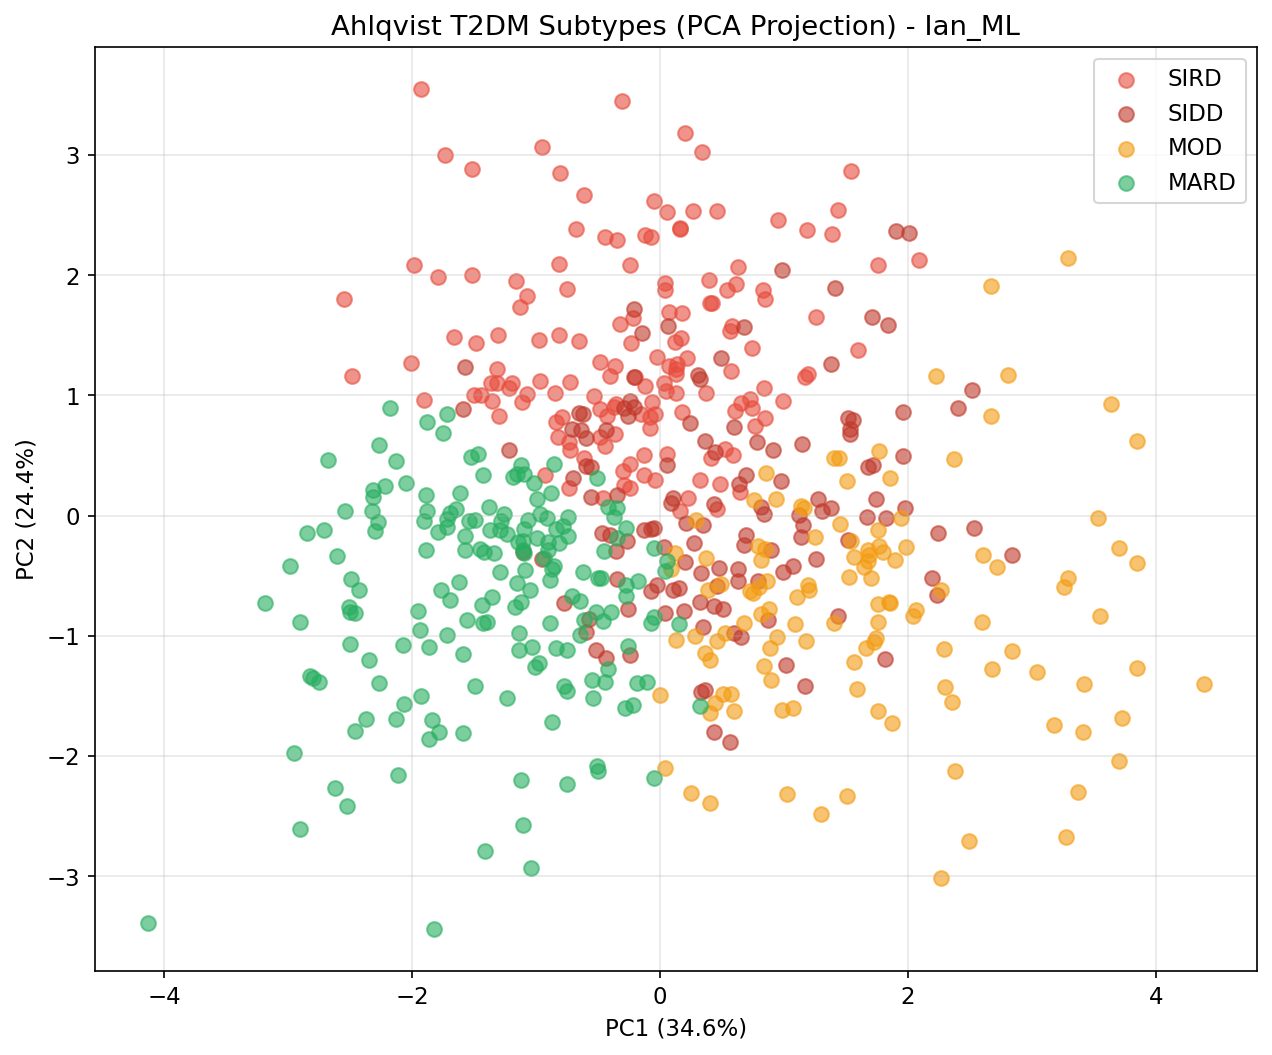

In [12]:
# PCA Projection to visualize the clusters
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 8))
colors = {'SIRD': '#e74c3c', 'SIDD': '#c0392b', 'MOD': '#f39c12', 'MARD': '#27ae60'}

for phenotype in ['SIRD', 'SIDD', 'MOD', 'MARD']:
    mask = df_clean['Phenotype'] == phenotype
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], 
                c=colors.get(phenotype, '#333'), 
                label=phenotype, alpha=0.6, s=50)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('Ahlqvist T2DM Subtypes (PCA Projection) - Ian_ML')
plt.legend()
plt.grid(alpha=0.3)
plt.show()